In [143]:
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/climate_watch")

df_test = pd.read_sql("SELECT * FROM GlobalLandTemperaturesByCity LIMIT 5", engine)
df_test


tables = [
    "GlobalLandTemperaturesByCity",
    "GlobalLandTemperaturesByCountry",
    "GlobalLandTemperaturesByMajorCity",
    "GlobalLandTemperaturesByState",
    "globaltemperatures"
]

with engine.connect() as conn:
    for table in tables:
        subset_table = f"{table}_subset"
        
        conn.execute(text(f"DROP TABLE IF EXISTS {subset_table}"))
        conn.execute(text(f"""
            CREATE TABLE {subset_table} AS
            SELECT *
            FROM {table}
            WHERE YEAR(dt) >= 1980;
        """))
        
        print(f"Klaar: {subset_table}")

conn.commit()

Klaar: GlobalLandTemperaturesByCity_subset
Klaar: GlobalLandTemperaturesByCountry_subset
Klaar: GlobalLandTemperaturesByMajorCity_subset
Klaar: GlobalLandTemperaturesByState_subset
Klaar: globaltemperatures_subset


In [144]:
for table in tables:
    subset_table = f"{table}_subset"
    
    df = pd.read_sql(f"SELECT * FROM {subset_table}", engine)
    
    print(f"\n--- {subset_table} ---")
    
    print("Missing per column:")
    print(df.isnull().sum())
    
    missing_rows = df[df.isnull().any(axis=1)]
    
    print(f"Rows with missing values: {len(missing_rows)}")


--- GlobalLandTemperaturesByCity_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByCountry_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
Country                          0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByMajorCity_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByState_subset --

In [145]:
for table in tables:
    subset_table = f"{table}_subset"
    
    df = pd.read_sql(f"SELECT * FROM {subset_table}", engine)
    
    print(f"\n--- {subset_table} ---")
    
    print("Missing per column:")
    print(df.isnull().sum())
    
    missing_rows = df[df.isnull().any(axis=1)]
    
    print(f"Rows with missing values: {len(missing_rows)}")


--- GlobalLandTemperaturesByCity_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByCountry_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
Country                          0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByMajorCity_subset ---
Missing per column:
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
dtype: int64
Rows with missing values: 0

--- GlobalLandTemperaturesByState_subset --

print(df.columns)


In [146]:
print(df.columns)

Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='str')


In [147]:
df["LandAverageTemperature"] = pd.to_numeric(
    df["LandAverageTemperature"], errors="coerce"
)


In [148]:
import numpy as np

df["LandAverageTemperature"] = df["LandAverageTemperature"].replace(0, np.nan)

In [149]:
df["LandAverageTemperature"] = df["LandAverageTemperature"].fillna(
    df["LandAverageTemperature"].mean()
    
)

In [150]:
temp_cols = [
    col for col in df.columns 
    if "Temperature" in col
]

for col in temp_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [151]:
# 1. Select ONLY real temperature columns (exclude uncertainty)
temp_cols = [
    col for col in df.columns 
    if "Temperature" in col and "Uncertainty" not in col
]

# 2. Replace 0 → NaN and fill with mean
for col in temp_cols:
    df[col] = (
        df[col]
        .replace(0, pd.NA)
        .fillna(df[col].mean())
    )

In [152]:
df[temp_cols].isna().sum()

LandAverageTemperature            0
LandMaxTemperature                0
LandMinTemperature                0
LandAndOceanAverageTemperature    0
dtype: int64

In [153]:
df[temp_cols].describe()

,LandAverageTemperature,LandMaxTemperature,LandMinTemperature,LandAndOceanAverageTemperature
count,432.000000,432.000000,432.000000,432.000000
mean,9.259451,14.964331,3.644563,15.655507
std,4.138503,4.252582,4.012910,1.229815
min,2.558000,8.090000,-2.853000,13.566000
25%,5.217000,10.710500,-0.296500,14.443500
50%,9.480500,15.207500,3.762000,15.732000
75%,13.224000,19.076250,7.500500,16.814250
max,15.482000,21.320000,9.715000,17.611000


In [154]:
df["dt"] = pd.to_datetime(df["dt"])
df["Year"] = df["dt"].dt.year

In [155]:
yearly_avg = df.groupby("Year")["LandAverageTemperature"].mean()

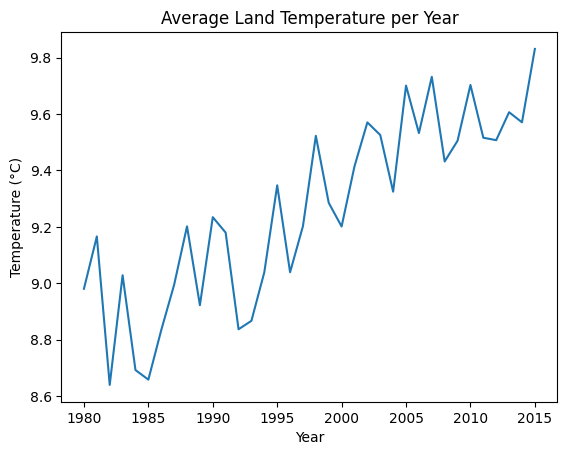

In [156]:
import matplotlib.pyplot as plt

yearly_avg.plot()
plt.title("Average Land Temperature per Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [157]:
country_df = pd.read_sql("SELECT * FROM GlobalLandTemperaturesByCountry_subset", engine)

country_df["AverageTemperature"] = pd.to_numeric(
    country_df["AverageTemperature"], errors="coerce"
)
country_df["AverageTemperature"] = country_df["AverageTemperature"].replace(0, pd.NA)
country_df["AverageTemperature"] = country_df["AverageTemperature"].fillna(
    country_df["AverageTemperature"].mean()
)

In [158]:
country_avg = country_df.groupby("Country")["AverageTemperature"].mean().sort_values()

In [159]:
coldest = country_avg.head(10)
hottest = country_avg.tail(10)

) missing from font(s) DejaVu Sans.k/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


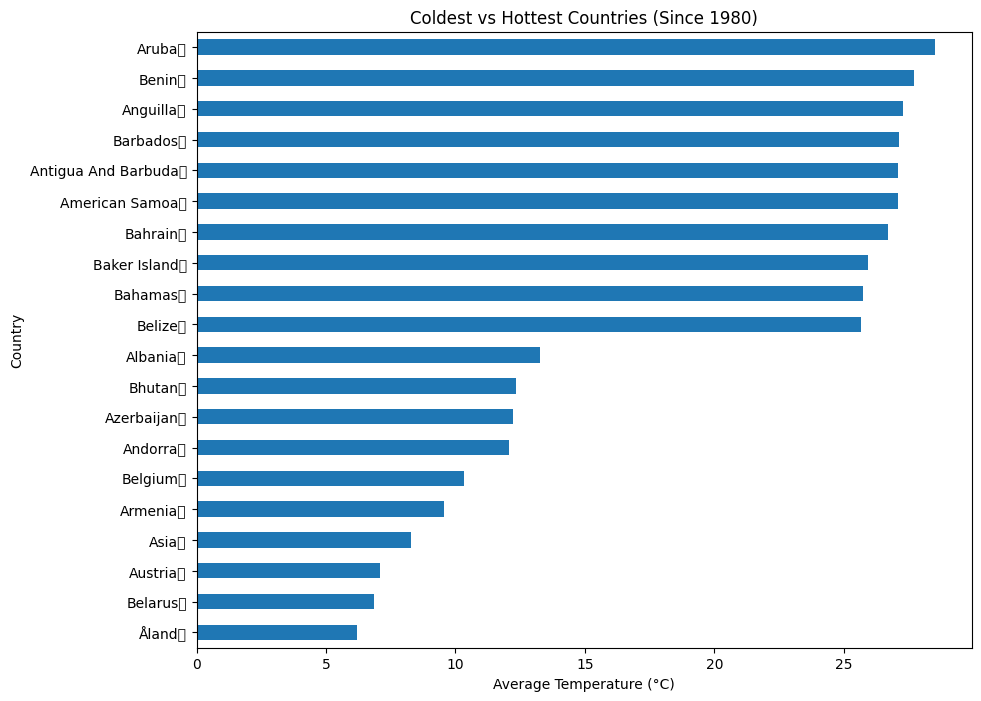

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

top_bottom = pd.concat([coldest, hottest])

plt.figure(figsize=(10, 8))
top_bottom.plot(kind="barh")
plt.title("Coldest vs Hottest Countries (Since 1980)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")
plt.show()

In [161]:
city_df = pd.read_sql(
    "SELECT * FROM GlobalLandTemperaturesByMajorCity_subset", engine
)

In [162]:
city_df["dt"] = pd.to_datetime(city_df["dt"])
city_df["Year"] = city_df["dt"].dt.year

city_df["AverageTemperature"] = pd.to_numeric(
    city_df["AverageTemperature"], errors="coerce"
)

# remove fake zeros if needed
city_df["AverageTemperature"] = city_df["AverageTemperature"].replace(0, pd.NA)

In [163]:
city_yearly = (
    city_df.groupby(["City", "Year"])["AverageTemperature"]
    .mean()
    .reset_index()
)

In [164]:
city_variation = (
    city_yearly.groupby("City")["AverageTemperature"]
    .agg(lambda x: x.max() - x.min())
    .sort_values(ascending=False)
)

In [165]:
top_cities = city_variation.head(5).index

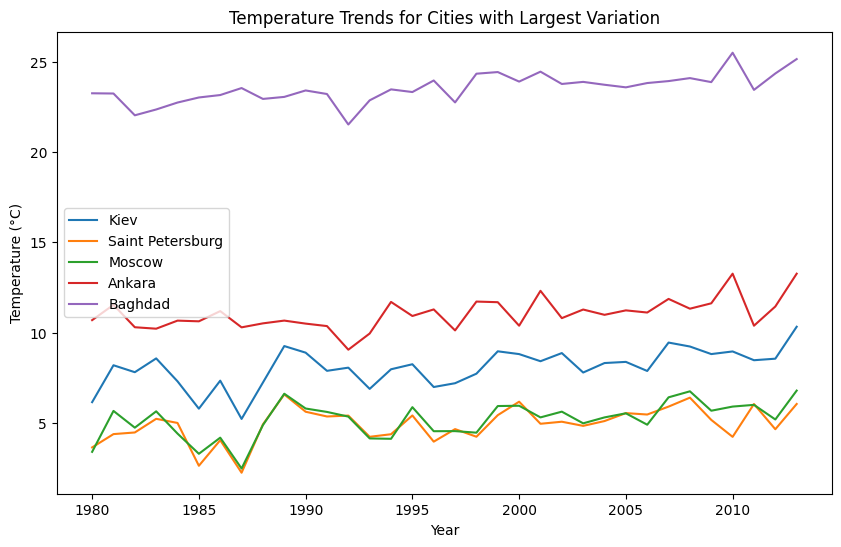

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for city in top_cities:
    data = city_yearly[city_yearly["City"] == city]
    plt.plot(data["Year"], data["AverageTemperature"], label=city)

plt.title("Temperature Trends for Cities with Largest Variation")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [167]:
df = pd.read_sql("SELECT * FROM globaltemperatures_subset", engine)

df["dt"] = pd.to_datetime(df["dt"])
df["Year"] = df["dt"].dt.year

# Convert uncertainty columns to numeric
uncertainty_cols = [
    "LandAverageTemperatureUncertainty",
    "LandAndOceanAverageTemperatureUncertainty"
]

for col in uncertainty_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [168]:
yearly_uncertainty = df.groupby("Year")[uncertainty_cols].mean()

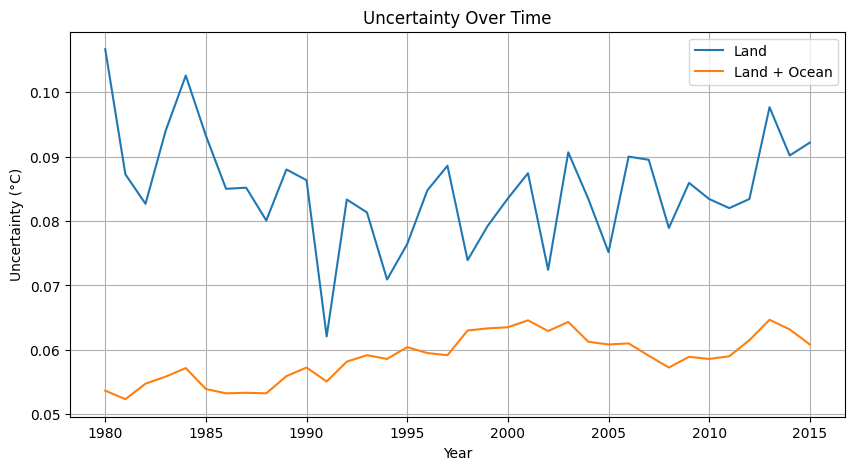

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_uncertainty.index,
    yearly_uncertainty["LandAverageTemperatureUncertainty"],
    label="Land"
)

plt.plot(
    yearly_uncertainty.index,
    yearly_uncertainty["LandAndOceanAverageTemperatureUncertainty"],
    label="Land + Ocean"
)

plt.title("Uncertainty Over Time")
plt.xlabel("Year")
plt.ylabel("Uncertainty (°C)")
plt.legend()
plt.grid()
plt.show()

In [170]:
yearly_uncertainty.sort_values(
    by="LandAverageTemperatureUncertainty",
    ascending=False
).head()

,LandAverageTemperatureUncertainty,LandAndOceanAverageTemperatureUncertainty
Year,,
1980,0.106667,0.053667
1984,0.102583,0.057167
2013,0.097667,0.064667
1983,0.094000,0.055833
1985,0.093250,0.053917


In [171]:
yearly_uncertainty.sort_values(
    by="LandAverageTemperatureUncertainty"
).head()

,LandAverageTemperatureUncertainty,LandAndOceanAverageTemperatureUncertainty
Year,,
1991,0.062083,0.055083
1994,0.070917,0.058583
2002,0.072417,0.062917
1998,0.073917,0.063000
2005,0.075167,0.060833


In [172]:
yearly_uncertainty.describe()

,LandAverageTemperatureUncertainty,LandAndOceanAverageTemperatureUncertainty
count,36.000000,36.000000
mean,0.084926,0.058847
std,0.008600,0.003639
min,0.062083,0.052333
25%,0.081021,0.055896
50%,0.084875,0.059042
75%,0.089625,0.061312
max,0.106667,0.064667


In [173]:
df[["Year", "LandAverageTemperatureUncertainty"]].corr()

,Year,LandAverageTemperatureUncertainty
Year,1.000000,-0.038282
LandAverageTemperatureUncertainty,-0.038282,1.000000


In [174]:
import pandas as pd
import plotly.express as px

df_country = pd.read_sql("""
    SELECT dt, AverageTemperature, Country
    FROM GlobalLandTemperaturesByCountry_subset
    WHERE AverageTemperature IS NOT NULL
""", engine)

df_country["dt"] = pd.to_datetime(df_country["dt"])
df_country["year"] = df_country["dt"].dt.year

country_yearly = df_country.groupby(["year", "Country"])["AverageTemperature"].mean().reset_index()
country_yearly = country_yearly[country_yearly["year"] >= 1900]

fig = px.choropleth(
    country_yearly,
    locations="Country",
    locationmode="country names",
    color="AverageTemperature",
    hover_name="Country",
    animation_frame="year",
    color_continuous_scale="RdYlBu_r",
    title="Gemiddelde temperatuur per land door de jaren heen"
)

fig.update_layout(height=700)
fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_80859/2483490208.py:16: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [180]:
import pandas as pd

# Landtemperaturen
land_df = pd.read_sql("""
SELECT dt, AverageTemperature
FROM GlobalLandTemperaturesByCountry_subset 
""", engine)

# Land + oceaan
global_df = pd.read_sql("""
SELECT dt, LandAndOceanAverageTemperature
FROM GlobalTemperatures_subset
""", engine)

# Datum naar datetime
land_df['dt'] = pd.to_datetime(land_df['dt'])
global_df['dt'] = pd.to_datetime(global_df['dt'])

# Jaar kolom
land_df['year'] = land_df['dt'].dt.year
global_df['year'] = global_df['dt'].dt.year

In [181]:
# Convert to numeric (force errors → NaN)
land_df['AverageTemperature'] = pd.to_numeric(
    land_df['AverageTemperature'], errors='coerce'
)

global_df['LandAndOceanAverageTemperature'] = pd.to_numeric(
    global_df['LandAndOceanAverageTemperature'], errors='coerce'
)

In [182]:
# Gemiddelde landtemperatuur per jaar
land_yearly = land_df.groupby('year')['AverageTemperature'].mean().reset_index()

# Gemiddelde land + oceaan per jaar
global_yearly = global_df.groupby('year')['LandAndOceanAverageTemperature'].mean().reset_index()

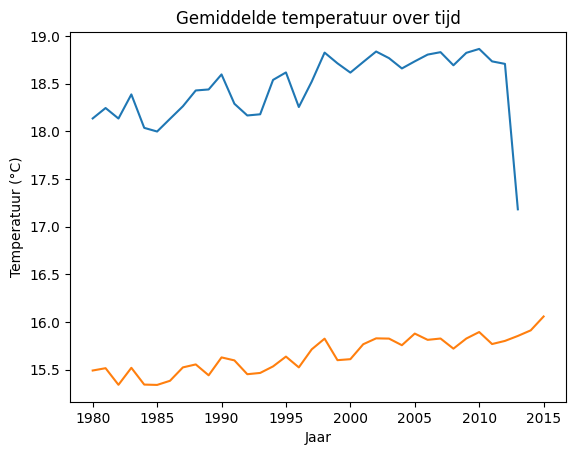

In [183]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(land_yearly['year'], land_yearly['AverageTemperature'])
plt.plot(global_yearly['year'], global_yearly['LandAndOceanAverageTemperature'])

plt.xlabel("Jaar")
plt.ylabel("Temperatuur (°C)")
plt.title("Gemiddelde temperatuur over tijd")

plt.show()

In [184]:
df = pd.read_sql("""
SELECT dt, AverageTemperature, Country
FROM GlobalLandTemperaturesByCountry
""", engine)

# Datum fix
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year

# Zorg dat temperatuur numeric is
df['AverageTemperature'] = pd.to_numeric(df['AverageTemperature'], errors='coerce')

# Drop rommel
df = df.dropna(subset=['AverageTemperature'])

In [185]:
country_avg = df.groupby('Country')['AverageTemperature'].mean().reset_index()

In [186]:
# Warmste
top_10_warm = country_avg.sort_values(by='AverageTemperature', ascending=False).head(10)

# Koudste
top_10_cold = country_avg.sort_values(by='AverageTemperature', ascending=True).head(10)

print("Warmste landen:\n", top_10_warm)
print("\nKoudste landen:\n", top_10_cold)

Warmste landen:
                                               Country  AverageTemperature
13                                            Aruba\r           25.578364
0   "Bonaire, Saint Eustatius And Saba"\r\n1824-02...           25.575000
19                                          Bahrain\r           25.487872
25                                           Belize\r           24.720284
5                                    American Samoa\r           24.617201
8                                          Anguilla\r           24.378343
22                                         Barbados\r           24.239144
10                              Antigua And Barbuda\r           24.220250
26                                            Benin\r           24.189539
21                                       Bangladesh\r           24.022347

Koudste landen:
          Country  AverageTemperature
9   Antarctica\r            0.000000
29       Åland\r            5.172127
23     Belarus\r            5.688134
16 

In [201]:
country = "Belgium\r"

country_df = df[df['Country'] == country]

country_yearly = country_df.groupby('year')['AverageTemperature'].mean().reset_index()

) missing from font(s) DejaVu Sans.k/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


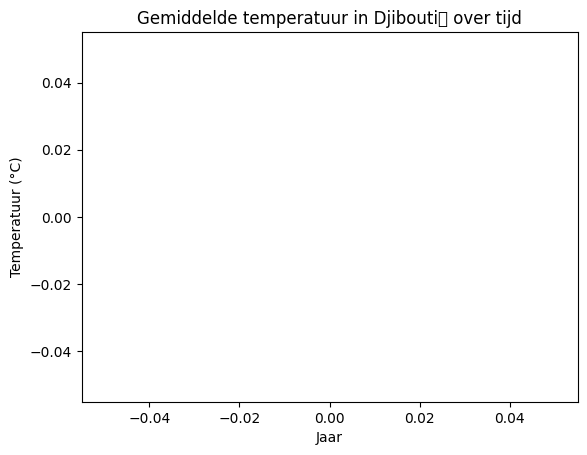

In [200]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(country_yearly['year'], country_yearly['AverageTemperature'])

plt.xlabel("Jaar")
plt.ylabel("Temperatuur (°C)")
plt.title(f"Gemiddelde temperatuur in {country} over tijd")

plt.show()

) missing from font(s) DejaVu Sans.x0wqh0000gn/T/ipykernel_80859/2388990298.py:61: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.k/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


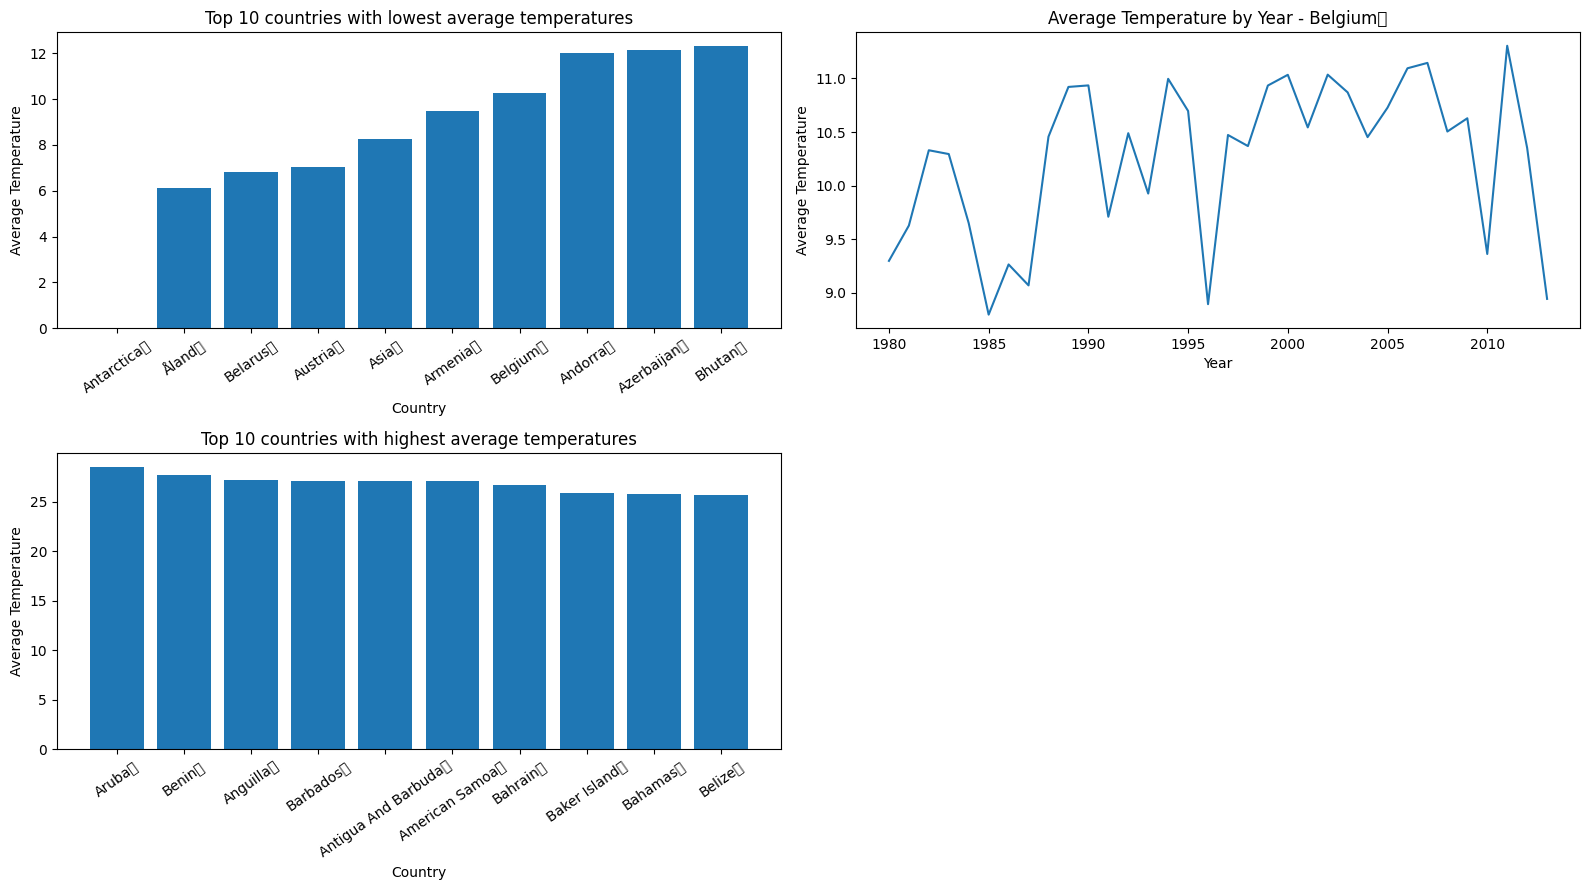

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from MySQL
df = pd.read_sql("""
    SELECT dt, Country, AverageTemperature
    FROM GlobalLandTemperaturesByCountry_subset
""", engine)

# Clean data
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df = df.dropna(subset=["AverageTemperature", "Country"])

# Average temperature per country
country_avg = (
    df.groupby("Country", as_index=False)["AverageTemperature"]
    .mean()
)

# Top 10 coldest and hottest countries
top_10_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)
top_10_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)

# Choose one country for the yearly trend
selected_country = "Belgium\r"

country_yearly = (
    df[df["Country"] == selected_country]
    .groupby("year", as_index=False)["AverageTemperature"]
    .mean()
)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Top left: coldest countries
axes[0, 0].bar(top_10_cold["Country"], top_10_cold["AverageTemperature"])
axes[0, 0].set_title("Top 10 countries with lowest average temperatures")
axes[0, 0].set_xlabel("Country")
axes[0, 0].set_ylabel("Average Temperature")
axes[0, 0].tick_params(axis="x", rotation=35)

# Bottom left: hottest countries
axes[1, 0].bar(top_10_hot["Country"], top_10_hot["AverageTemperature"])
axes[1, 0].set_title("Top 10 countries with highest average temperatures")
axes[1, 0].set_xlabel("Country")
axes[1, 0].set_ylabel("Average Temperature")
axes[1, 0].tick_params(axis="x", rotation=35)

# Right: yearly trend for one country
axes[0, 1].plot(country_yearly["year"], country_yearly["AverageTemperature"])
axes[0, 1].set_title(f"Average Temperature by Year - {selected_country}")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Average Temperature")

# Hide empty bottom-right subplot
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

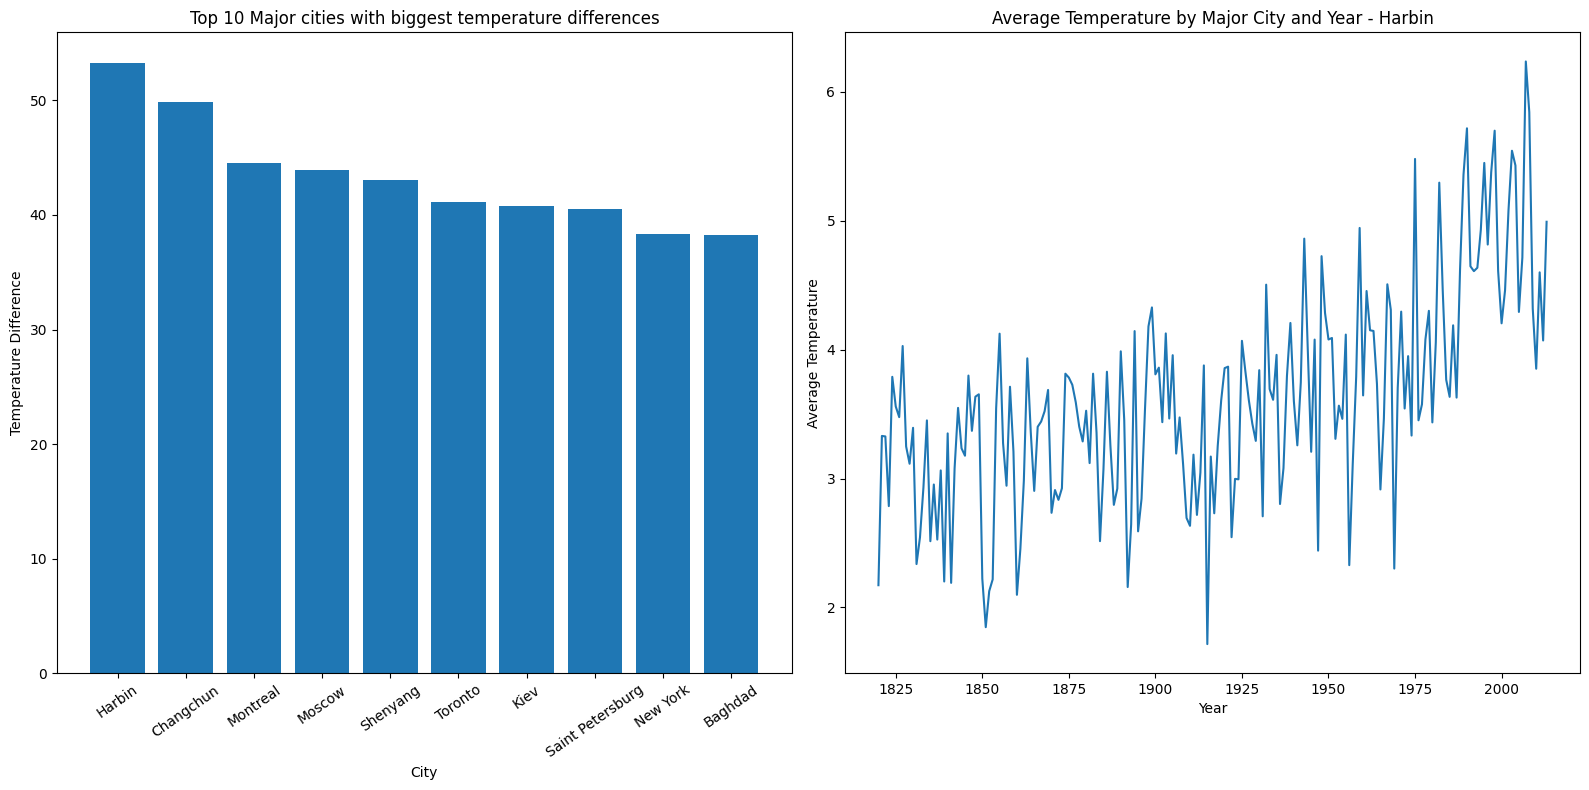

In [205]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_sql("""
    SELECT dt, City, AverageTemperature
    FROM GlobalLandTemperaturesByMajorCity
""", engine)

# Clean data
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df = df.dropna(subset=["AverageTemperature", "City"])

# Calculate temperature difference per city
city_diff = (
    df.groupby("City")["AverageTemperature"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="TemperatureDifference")
)

# Top 10 cities with biggest temperature differences
top_10_diff = city_diff.sort_values(by="TemperatureDifference", ascending=False).head(10)

# Select one city for yearly trend
selected_city = "Harbin"

city_yearly = (
    df[df["City"] == selected_city]
    .groupby("year", as_index=False)["AverageTemperature"]
    .mean()
)

# Layout
fig = plt.figure(figsize=(16, 8))

ax1 = plt.subplot2grid((1, 2), (0, 0))
ax2 = plt.subplot2grid((1, 2), (0, 1))

# Bar chart
ax1.bar(top_10_diff["City"], top_10_diff["TemperatureDifference"])
ax1.set_title("Top 10 Major cities with biggest temperature differences")
ax1.set_xlabel("City")
ax1.set_ylabel("Temperature Difference")
ax1.tick_params(axis="x", rotation=35)

# Line chart
ax2.plot(city_yearly["year"], city_yearly["AverageTemperature"])
ax2.set_title(f"Average Temperature by Major City and Year - {selected_city}")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average Temperature")

plt.tight_layout()
plt.show()

In [209]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_sql("""
    SELECT dt,
           LandAverageTemperatureUncertainty,
           LandAndOceanAverageTemperatureUncertainty
    FROM GlobalTemperatures
""", engine)

# Clean
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year

df["LandAverageTemperatureUncertainty"] = pd.to_numeric(
    df["LandAverageTemperatureUncertainty"], errors="coerce"
)

df["LandAndOceanAverageTemperatureUncertainty"] = pd.to_numeric(
    df["LandAndOceanAverageTemperatureUncertainty"], errors="coerce"
)

df = df.dropna()

# Group per year (average uncertainty)
uncertainty_yearly = df.groupby("year").mean().reset_index()

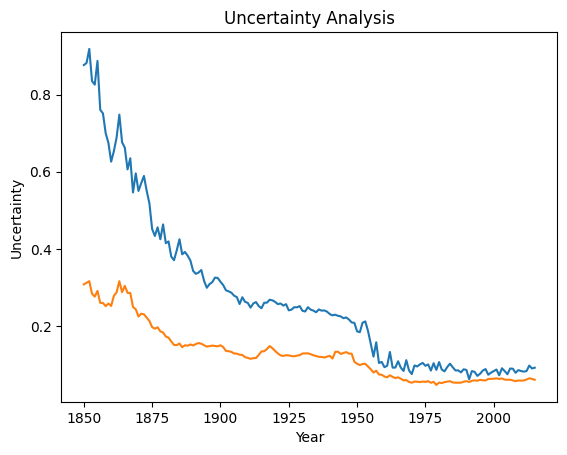

In [210]:
plt.figure()

plt.plot(
    uncertainty_yearly["year"],
    uncertainty_yearly["LandAverageTemperatureUncertainty"],
)

plt.plot(
    uncertainty_yearly["year"],
    uncertainty_yearly["LandAndOceanAverageTemperatureUncertainty"],
)

plt.xlabel("Year")
plt.ylabel("Uncertainty")
plt.title("Uncertainty Analysis")

plt.show()

ValueError: could not convert string to float: '3.23W'

In [211]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_sql("""
    SELECT City, Latitude, Longitude, AverageTemperature
    FROM GlobalLandTemperaturesByMajorCity
""", engine)

# Clean data
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df = df.dropna(subset=["AverageTemperature", "Latitude", "Longitude"])

# Average temperature per city
city_avg = (
    df.groupby(["City", "Latitude", "Longitude"], as_index=False)
    ["AverageTemperature"]
    .mean()
)

# Plot world map
fig = px.scatter_geo(
    city_avg,
    lat="Latitude",
    lon="Longitude",
    color="AverageTemperature",
    hover_name="City",
    title="Average Temperature of Cities around the World"
)

fig.show()

In [216]:
import plotly.express as px

city_avg = (
    df.groupby(["City", "Latitude", "Longitude"], as_index=False)
    ["AverageTemperature"]
    .mean()
)

fig = px.scatter_geo(
    city_avg,
    lat="Latitude",
    lon="Longitude",
    color="AverageTemperature",
    hover_name="City",
    color_continuous_scale="RdYlGn_r",
    title="Average Temperature of Cities around the World"
)

fig.show()

In [214]:
print(df.columns)

Index(['City', 'Latitude', 'Longitude', 'AverageTemperature'], dtype='str')
